# Numerical analysis

We consider $d=2$, three communities with priors $\pi=(0.5,0.3,0.2)$, and $r=3$.
For $p\in[1/2,1)$,
$$
P_{ab}(y)=
\begin{cases}
\operatorname{Ber}(p), & a=b,\quad y\in[0,r/3)\cup(2r/3,r],\\
\operatorname{Ber}(1-p), & a\neq b,\quad y\in[0,r/3)\cup(2r/3,r],\\
\operatorname{Ber}(1/2), & y\in[r/3,2r/3].
\end{cases}
$$
For this model,
$$
D_+(p)=\frac{1-2\sqrt{p(1-p)}}{3},\qquad
\ell=\frac r3,\qquad
\pi_{\mathrm{wit}}=\frac12.
$$

The initialization is oracle on the centered square with half-side $r\sqrt{\log n}$. Only Greedy followed by refinement is simulated.

In [1]:
from dataclasses import dataclass
from math import gamma, pi
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
from scipy.spatial import cKDTree

K, DIM, R = 3, 2, 3.0
PRIORS = np.array([0.5, 0.3, 0.2])
L_WIT, PI_WIT = R / 3, 0.5

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

def unit_ball_volume(d):
    return pi ** (d / 2) / gamma(d / 2 + 1)

def profile_matrices(p):
    P = np.full((K, K), 1 - p)
    np.fill_diagonal(P, p)
    return np.stack([P, np.full((K, K), 0.5), P])

def dplus(p):
    return (1 - 2 * np.sqrt(p * (1 - p))) / 3

def p_from_dplus(D):
    if not 0 <= D < 1 / 3:
        raise ValueError("Need 0 <= D_+ < 1/3.")
    return 0.5 * (1 + np.sqrt(1 - (1 - 3 * D) ** 2))

def visibility_threshold():
    return 1 / (unit_ball_volume(DIM) * R**DIM)

def witness_threshold():
    return 1 / (unit_ball_volume(DIM) * L_WIT**DIM * PI_WIT)

In [2]:
@dataclass
class GHCMInstance:
    n: int
    lam: float
    p: float
    positions: np.ndarray
    truth: np.ndarray
    box_length: float
    visibility_radius: float
    log_scale: float
    logP: np.ndarray
    logQ: np.ndarray
    indptr: np.ndarray
    indices: np.ndarray
    observations: np.ndarray
    bands: np.ndarray

    @property
    def N(self):
        return len(self.truth)

    def neighbors(self, u):
        s = slice(self.indptr[u], self.indptr[u + 1])
        return self.indices[s], self.observations[s], self.bands[s]

def sample_ghcm(n, lam, p, seed):
    rng = np.random.default_rng(seed)
    box, log_scale = np.sqrt(n), np.sqrt(np.log(n))
    radius = R * log_scale
    N = int(rng.poisson(lam * n))
    positions = rng.uniform(0, box, size=(N, DIM))
    truth = rng.choice(K, size=N, p=PRIORS).astype(np.int8)

    P = profile_matrices(p)
    tree = cKDTree(positions, boxsize=box)
    pairs = tree.query_pairs(radius, output_type="ndarray").astype(np.int32)

    if len(pairs):
        delta = np.abs(positions[pairs[:, 0]] - positions[pairs[:, 1]])
        delta = np.minimum(delta, box - delta)
        y = np.sqrt(np.sum(delta * delta, axis=1)) / log_scale
        pair_bands = np.where(y < R / 3, 0, np.where(y <= 2 * R / 3, 1, 2)).astype(np.int8)
        probs = P[pair_bands, truth[pairs[:, 0]], truth[pairs[:, 1]]]
        pair_obs = (rng.random(len(pairs)) < probs).astype(np.int8)

        u = np.r_[pairs[:, 0], pairs[:, 1]]
        v = np.r_[pairs[:, 1], pairs[:, 0]]
        obs = np.r_[pair_obs, pair_obs]
        band = np.r_[pair_bands, pair_bands]
        order = np.argsort(u, kind="stable")
        u, v, obs, band = u[order], v[order], obs[order], band[order]
        counts = np.bincount(u, minlength=N)
        indptr = np.r_[0, np.cumsum(counts)]
    else:
        v = np.empty(0, dtype=np.int32)
        obs = band = np.empty(0, dtype=np.int8)
        indptr = np.zeros(N + 1, dtype=np.int64)

    return GHCMInstance(
        n, lam, p, positions, truth, box, radius, log_scale,
        np.log(P), np.log1p(-P), indptr,
        v.astype(np.int32, copy=False), obs, band
    )

In [3]:
def oracle_initialization(G):
    center = np.full(DIM, G.box_length / 2)
    delta = np.abs(G.positions - center)
    delta = np.minimum(delta, G.box_length - delta)
    vertices = np.flatnonzero(np.all(delta <= G.visibility_radius, axis=1))
    labels = np.full(G.N, -1, dtype=np.int8)
    labels[vertices] = G.truth[vertices]
    return labels, vertices

def classify_vertex(G, u, labels):
    nbr, obs, band = G.neighbors(u)
    keep = labels[nbr] >= 0
    nbr, obs, band = nbr[keep], obs[keep], band[keep]
    if len(nbr) == 0:
        return -1

    source = labels[nbr].astype(np.int64, copy=False)
    scores = np.empty(K)
    for a in range(K):
        lp, lq = G.logP[band, a, source], G.logQ[band, a, source]
        scores[a] = np.sum(np.where(obs == 1, lp, lq))
    return int(np.argmax(scores))

def greedy_score(counts):
    return int(counts.sum() - counts.max())

def greedy_propagation(G, initial_labels):
    labels = initial_labels.copy()
    counts = np.zeros((G.N, K), dtype=np.int16)

    for v in np.flatnonzero(labels >= 0):
        nbr, _, band = G.neighbors(int(v))
        use = (labels[nbr] < 0) & (band != 1)
        np.add.at(counts, (nbr[use], labels[v]), 1)

    max_degree = int(np.diff(G.indptr).max(initial=0))
    buckets = [set() for _ in range(max_degree + 2)]
    scores = np.zeros(G.N, dtype=np.int16)
    current_max = 0

    for u in np.flatnonzero(labels < 0):
        s = greedy_score(counts[u])
        scores[u] = s
        buckets[s].add(int(u))
        current_max = max(current_max, s)

    remaining = int(np.sum(labels < 0))
    while remaining:
        while current_max > 0 and not buckets[current_max]:
            current_max -= 1
        if not buckets[current_max]:
            break

        u = buckets[current_max].pop()
        if labels[u] >= 0:
            continue

        label = classify_vertex(G, u, labels)
        if label < 0:
            continue

        labels[u] = label
        remaining -= 1
        nbr, _, band = G.neighbors(u)
        use = (labels[nbr] < 0) & (band != 1)

        for v in nbr[use]:
            old = int(scores[v])
            counts[v, label] += 1
            new = greedy_score(counts[v])
            if new != old:
                buckets[old].discard(int(v))
                buckets[new].add(int(v))
                scores[v] = new
                current_max = max(current_max, new)

    return labels

def refine(G, labels):
    old = labels.copy()
    return np.array([classify_vertex(G, u, old) for u in range(G.N)], dtype=np.int8)

def run_trial(n, lam, p, seed):
    G = sample_ghcm(n, lam, p, seed)
    initial, seed_vertices = oracle_initialization(G)
    phase1 = greedy_propagation(G, initial)
    final = refine(G, phase1)
    return {
        "n": n, "N": G.N, "lambda": lam, "p": p, "Dplus": dplus(p),
        "seed_fraction": len(seed_vertices) / max(G.N, 1),
        "phase1_fraction": np.mean(phase1 >= 0) if G.N else np.nan,
        "before_exact": int(np.array_equal(phase1, G.truth)),
        "after_exact": int(np.array_equal(final, G.truth)),
    }

In [4]:
@dataclass(frozen=True)
class AdaptiveCell:
    l0: float
    l1: float
    d0: float
    d1: float
    depth: int
    near_boundary: bool

    @property
    def center(self):
        return (self.l0 + self.l1) / 2, (self.d0 + self.d1) / 2

def adaptive_cells(lambda_min=0.0, lambda_max=1.75, D_min=0.0, D_max=1/3, max_depth=2):
    c = unit_ball_volume(DIM) * R**DIM
    breaks = sorted({lambda_min, lambda_max, *[x for x in (visibility_threshold(), witness_threshold()) if lambda_min < x < lambda_max]})
    leaves = []

    def split(l0, l1, d0, d1, depth):
        crosses = l0 * c * d0 <= 1 <= l1 * c * d1
        if crosses and depth < max_depth:
            lm, dm = (l0 + l1) / 2, (d0 + d1) / 2
            for a, b, x, y in [(l0, lm, d0, dm), (l0, lm, dm, d1),
                               (lm, l1, d0, dm), (lm, l1, dm, d1)]:
                split(a, b, x, y, depth + 1)
        else:
            leaves.append(AdaptiveCell(l0, l1, d0, d1, depth, crosses))

    for l0, l1 in zip(breaks[:-1], breaks[1:]):
        split(l0, l1, D_min, D_max, 0)
    return leaves

def run_greedy_heatmap(cells, n=20_000, trials_bulk=3, trials_boundary=10,
                       seed=20260811, n_jobs=1):
    tasks = []
    for cell_id, cell in enumerate(cells):
        lam, D = cell.center
        p = p_from_dplus(D)
        trials = trials_boundary if cell.near_boundary else trials_bulk
        tasks += [(cell_id, cell, trial, lam, p) for trial in range(trials)]

    def one(task):
        cell_id, cell, trial, lam, p = task
        row = run_trial(n, lam, p, seed + 100000 * cell_id + trial)
        row.update(cell_id=cell_id, trial=trial, l0=cell.l0, l1=cell.l1,
                   d0=cell.d0, d1=cell.d1, depth=cell.depth,
                   near_boundary=int(cell.near_boundary))
        return row

    rows = [one(t) for t in tasks] if n_jobs == 1 else Parallel(n_jobs=n_jobs, prefer="processes")(
        delayed(one)(t) for t in tasks
    )
    raw = pd.DataFrame(rows)
    raw.to_csv(RESULTS_DIR / "greedy_heatmap_trials.csv", index=False)

    cells_df = raw.groupby(
        ["cell_id", "l0", "l1", "d0", "d1", "depth", "near_boundary"], as_index=False
    ).agg(
        trials=("trial", "count"),
        exact_recovery_frequency=("after_exact", "mean"),
        mean_seed_fraction=("seed_fraction", "mean"),
    )
    cells_df.to_csv(RESULTS_DIR / "greedy_heatmap_cells.csv", index=False)
    return raw, cells_df

In [22]:
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",

    "font.family": "serif",
    "mathtext.fontset": "stix",

    "font.size": 18,
    "axes.labelsize": 28,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    "axes.linewidth": 1.5,
    "axes.grid": False,

    "xtick.direction": "out",
    "ytick.direction": "out",

    "savefig.bbox": "tight",
    "savefig.dpi": 300,

    "svg.fonttype": "none",
    "pdf.fonttype": 42,
})


def plot_greedy_heatmap(
    data: pd.DataFrame,
    *,
    lambda_max=1.75,
    D_max=1 / 3,
):
    # Couleurs du style précédent
    color_A = (0.96, 0.78, 0.76)  # pastel red
    color_B = (0.98, 0.88, 0.68)  # pastel yellow
    color_C = (0.79, 0.90, 0.81)  # pastel green

    # Colormap pastel rouge -> jaune -> vert
    cmap = LinearSegmentedColormap.from_list(
        "pastel_RdYlGn",
        [color_A, color_B, color_C],
        N=256,
    )

    fig, ax = plt.subplots(figsize=(14.5, 7.6) , constrained_layout=True)

    # --------------------------------------------------
    # Heatmap par rectangles
    # --------------------------------------------------

    patches = [
        Rectangle(
            (row.l0, row.d0),
            row.l1 - row.l0,
            row.d1 - row.d0,
        )
        for row in data.itertuples()
    ]

    collection = PatchCollection(
        patches,
        cmap=cmap,
        edgecolor="0.78",
        linewidth=0.35,
        zorder=1,
    )
    collection.set_array(
        data["exact_recovery_frequency"].to_numpy()
    )
    collection.set_clim(0, 1)
    ax.add_collection(collection)

    # --------------------------------------------------
    # Courbe et seuils
    # --------------------------------------------------

    nu = unit_ball_volume(DIM)

    lam_start = 1 / (nu * R**DIM * D_max)
    lam = np.linspace(lam_start, lambda_max, 900)

    visibility_x = visibility_threshold()
    witness_x = witness_threshold()

    curve = 1 / (nu * R**DIM * lam)

    ax.plot(
        lam,
        curve,
        color="black",
        linewidth=2.4,
        zorder=3,
    )

    ax.axvline(
        visibility_x,
        color="black",
        linestyle="--",
        linewidth=1.8,
        zorder=2,
    )

    ax.axvline(
        witness_x,
        color="black",
        linestyle="--",
        linewidth=1.8,
        zorder=2,
    )

    # --------------------------------------------------
    # Axes
    # --------------------------------------------------

    ax.set_xlim(0, lambda_max)
    ax.set_ylim(0, D_max)

    ax.set_xlabel(r"$\lambda$", fontsize=34)
    ax.set_ylabel(r"$D_+$", fontsize=34)

    # ticks propres
    xticks = np.linspace(0, lambda_max, 6)
    yticks = np.linspace(0, D_max, 6)

    ax.set_xticks(xticks)
    ax.set_yticks(yticks)

    ax.set_xticklabels([f"{x:.2f}" for x in xticks])
    ax.set_yticklabels([f"{y:.2f}" for y in yticks])

    # --------------------------------------------------
    # Labels LaTeX directement sur les lignes
    # --------------------------------------------------

    # label de la courbe
    lambda_curve = 0.74 * lambda_max
    D_curve = 1 / (nu * R**DIM * lambda_curve)

    ax.text(
        lambda_curve,
        D_curve + 0.03 * D_max,
        r"$\lambda \nu_d r^d D_+ = 1$",
        fontsize=40,
        ha="center",
        va="bottom",
        zorder=4,
    )

    # label sur la première ligne verticale
    ax.text(
        visibility_x+0.1*lambda_max,
        0.1 * D_max,
        r"$\lambda \nu_d r^d = 1$",
        fontsize=40,
        rotation=0,
        ha="center",
        va="center",
        zorder=4,
    )

    # label sur la deuxième ligne verticale
    ax.text(
        witness_x+0.14*lambda_max,
        0.9* D_max,
        (
            r"$\lambda \nu_d \ell^d"
            r"\pi_{\mathrm{wit}} = 1$"
        ),
        fontsize=40,
        rotation=0,
        ha="center",
        va="center",
        zorder=4,
    )

    # --------------------------------------------------
    # Colorbar
    # --------------------------------------------------

    cbar = fig.colorbar(
        collection,
        ax=ax,
        pad=0.015,
    )
    cbar.set_label(
        "exact-recovery frequency",
        fontsize=18,
    )
    cbar.ax.tick_params(labelsize=16)

    return fig, ax

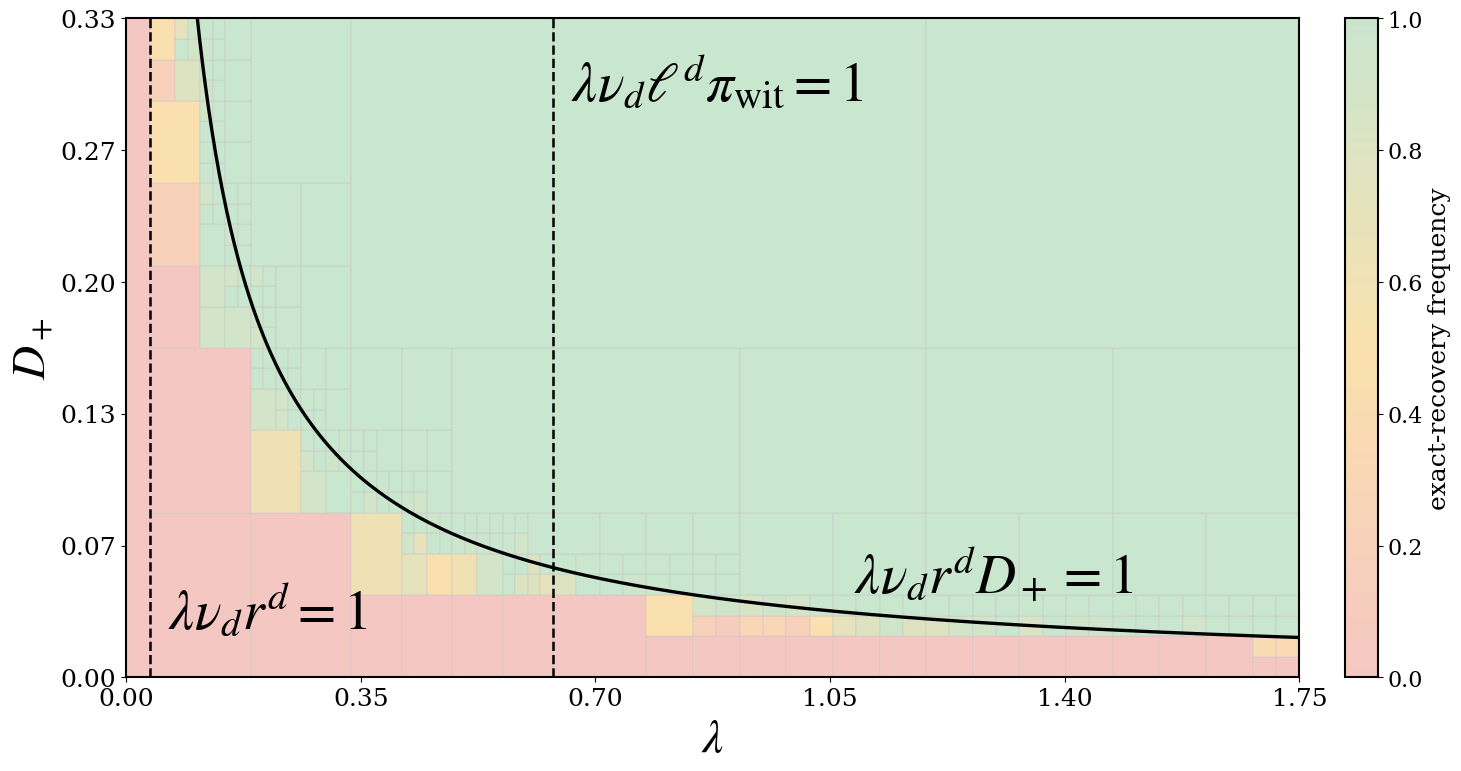

In [23]:
# Really long experiment, 5h on 4 cores, 10k nodes, 10 bulk trials, 20 boundary trials, max depth 5
# Decrease max-depth, n, bulk/boundary trials to reduce runtime for testing purposes

# Main experiment
N = 10_000
TRIALS_BULK = 10
TRIALS_BOUNDARY = 20
MAX_DEPTH = 5
N_JOBS = 4

#### Run
# CELLS = adaptive_cells(max_depth=MAX_DEPTH)
# heatmap_raw, heatmap_cells = run_greedy_heatmap(
#     CELLS, n=N, trials_bulk=TRIALS_BULK,
#     trials_boundary=TRIALS_BOUNDARY, n_jobs=N_JOBS
# )

#### Load previously computed results
heatmap_raw = pd.read_csv(RESULTS_DIR / "greedy_heatmap_trials.csv")
heatmap_cells = pd.read_csv(RESULTS_DIR / "greedy_heatmap_cells.csv")

fig, ax = plot_greedy_heatmap(heatmap_cells)
fig.savefig(RESULTS_DIR / "greedy_heatmap.pdf", dpi=300, bbox_inches="tight")
plt.show()